<a href="https://colab.research.google.com/github/UKD1211/Macroeconomic_impact_of_gold-_Econ_growth/blob/main/Gold_price_Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use('default')

sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (14,6)
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

In [2]:
df = pd.read_excel("/content/Master_Dataset.xlsx")

In [3]:
df

,Date,Gold_Reservs_USD_mn,Gold_Volume_mn_troy_oz,Gold_Price[/10gm],Gold_CPI,USDINR,Repo_Rate,Overall_CPI,Inflation_YoY,Inflation_MoM,FPI_Net_INR_Crore,"GDP, current prices (Billions of U.S. dollars)","GDP per capita, current prices\n (U.S. dollars per capita)",Real GDP growth (Annual percent change),Remittances received (Personal remittances received current U.S. $)
0,2000-01,2945.0,11.502339,4510.75,---,43.59,---,---,---,---,196.5,468.396,442.751,3.8,12883465957.0616
1,2000-02,3104.0,11.502339,4712.25,---,43.65,---,---,---,---,3084.2,468.396,442.751,3.8,12883465957.0616
2,2000-03,2974.0,11.502339,4541.90,---,43.64,---,---,---,---,1198.9,468.396,442.751,3.8,12883465957.0616
3,2000-04,2895.0,11.502339,4462.06,---,43.68,---,---,---,---,2586.7,468.396,442.751,3.8,12883465957.0616
4,2000-05,2851.0,11.502339,4371.14,---,44.08,---,---,---,---,252.9,468.396,442.751,3.8,12883465957.0616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,2025-11,106740.0,28.298487,122834.00,408.4,88.84,5.5,197.9,0.71,0.3,2836.0,3916.312,2675.322,7.6,---
311,2025-12,111262.0,28.303688,131322.55,433.9,90.04,5.25,198,1.33,0.05,-38568.0,3916.312,2675.322,7.6,---
312,2026-01,126904.0,28.303707,146169.80,---,90.90,5.25,---,2.38,0,-29240.0,---,---,---,---
313,2026-02,131630.0,28.303709,154370.40,---,90.75,5.25,---,2.86,0,37804.0,---,---,---,---


In [4]:
#sort dataset

df = df.sort_values("Date").reset_index(drop = True)
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace = True)

In [5]:
gold_price = df['Gold_Price[/10gm]']

In [6]:
gold_price

,Gold_Price[/10gm]
Date,
2000-01-01,4510.75
2000-02-01,4712.25
2000-03-01,4541.90
2000-04-01,4462.06
2000-05-01,4371.14
...,...
2025-11-01,122834.00
2025-12-01,131322.55
2026-01-01,146169.80


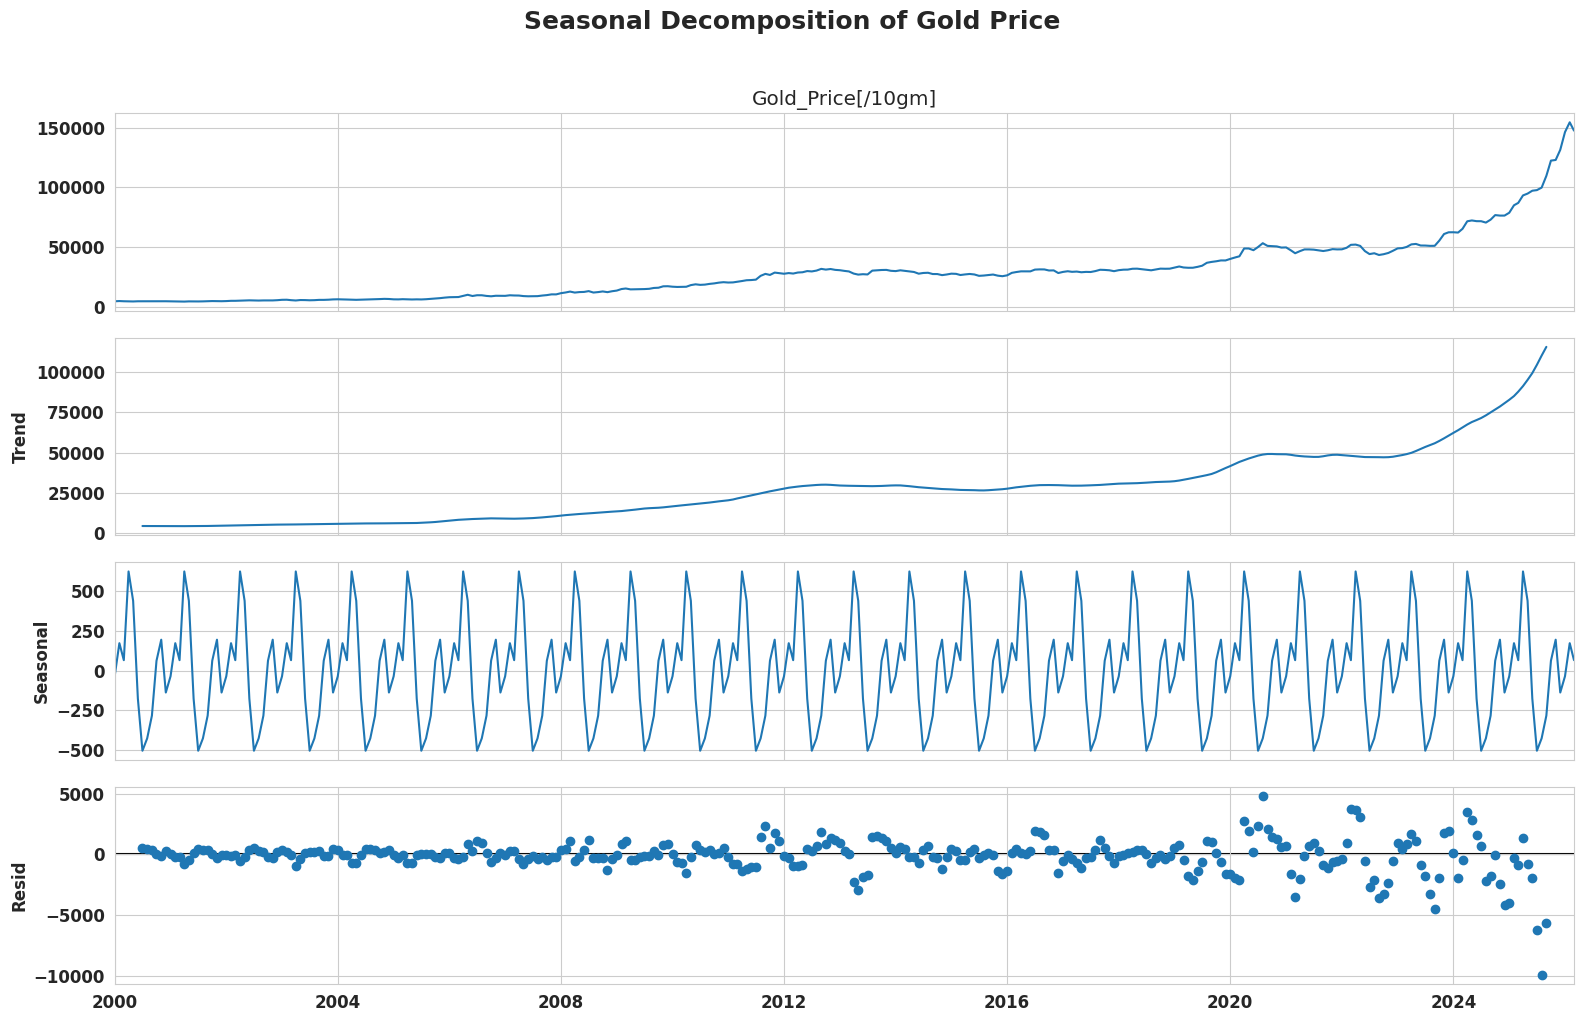

In [7]:
#gold_price_decompose

decomposition = seasonal_decompose(
    gold_price,
    model='additive',
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(16,10)

plt.suptitle(
    "Seasonal Decomposition of Gold Price",
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.show()

In [8]:
# Monthly Gold Return (%)

df['Gold_Return_%'] = (
    df['Gold_Price[/10gm]']
    .pct_change() * 100
)

In [9]:
gold_return = df['Gold_Return_%'].dropna()

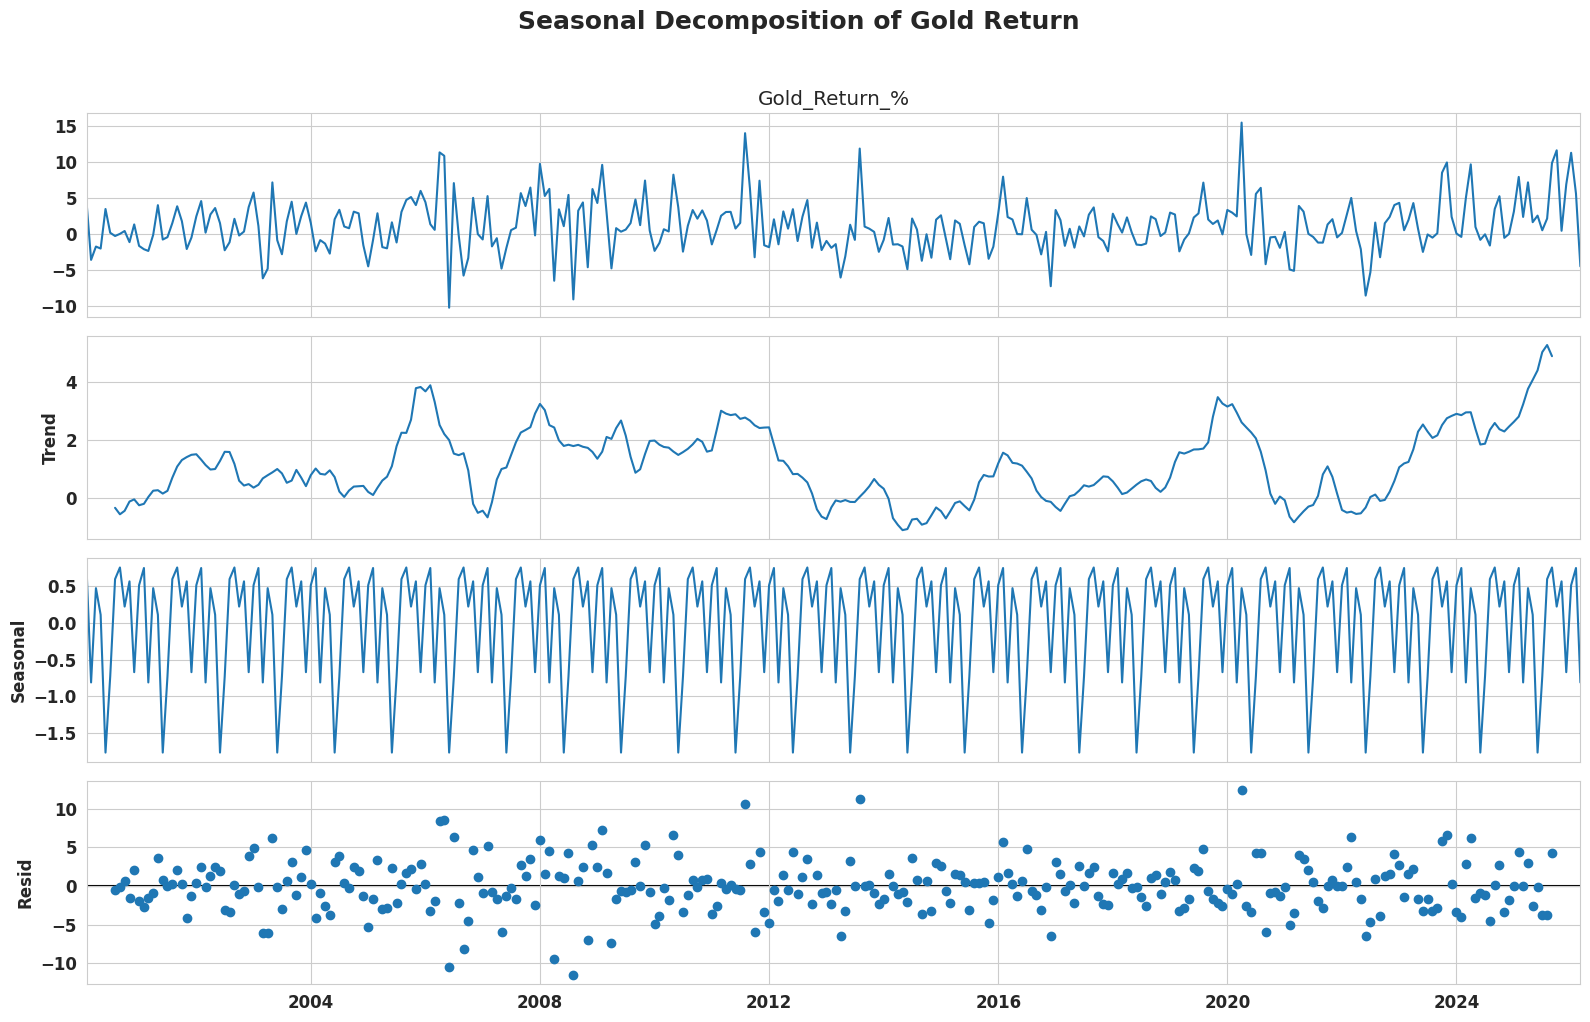

In [10]:
#Gold Return seasonal Decompose
decomposition_return = seasonal_decompose(
    gold_return,
    model='additive',
    period=12
)

fig = decomposition_return.plot()

fig.set_size_inches(16,10)

plt.suptitle(
    "Seasonal Decomposition of Gold Return",
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.show()

In [11]:
#visual representation of the Stationarity check

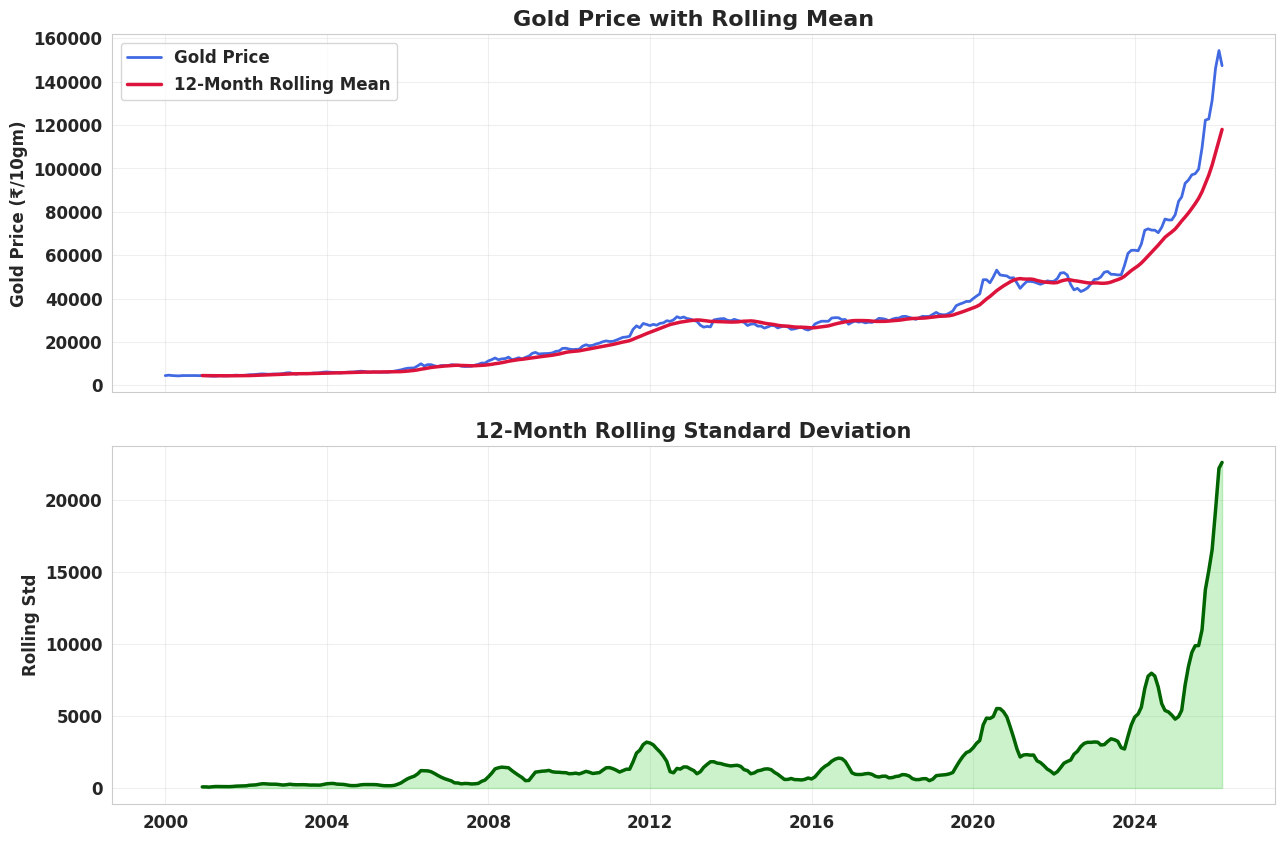

In [12]:
window = 12  # 12 months

rolling_mean = gold_price.rolling(window=window).mean()
rolling_std = gold_price.rolling(window=window).std()

fig, axes = plt.subplots(
    2, 1,
    figsize=(15,10),
    sharex=True,
    gridspec_kw={'hspace':0.15}
)

# -------------------------------
# Rolling Mean
# -------------------------------

axes[0].plot(
    gold_price,
    color='royalblue',
    linewidth=2,
    label='Gold Price'
)

axes[0].plot(
    rolling_mean,
    color='crimson',
    linewidth=2.5,
    label='12-Month Rolling Mean'
)

axes[0].set_title(
    'Gold Price with Rolling Mean',
    fontsize=16,
    fontweight='bold'
)

axes[0].set_ylabel('Gold Price (₹/10gm)')
axes[0].legend(frameon=True)
axes[0].grid(alpha=0.3)

# -------------------------------
# Rolling Standard Deviation
# -------------------------------

axes[1].plot(
    rolling_std,
    color='darkgreen',
    linewidth=2.5
)

axes[1].fill_between(
    rolling_std.index,
    rolling_std.values,
    color='limegreen',
    alpha=0.25
)

axes[1].set_title(
    '12-Month Rolling Standard Deviation',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_ylabel('Rolling Std')
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.show()

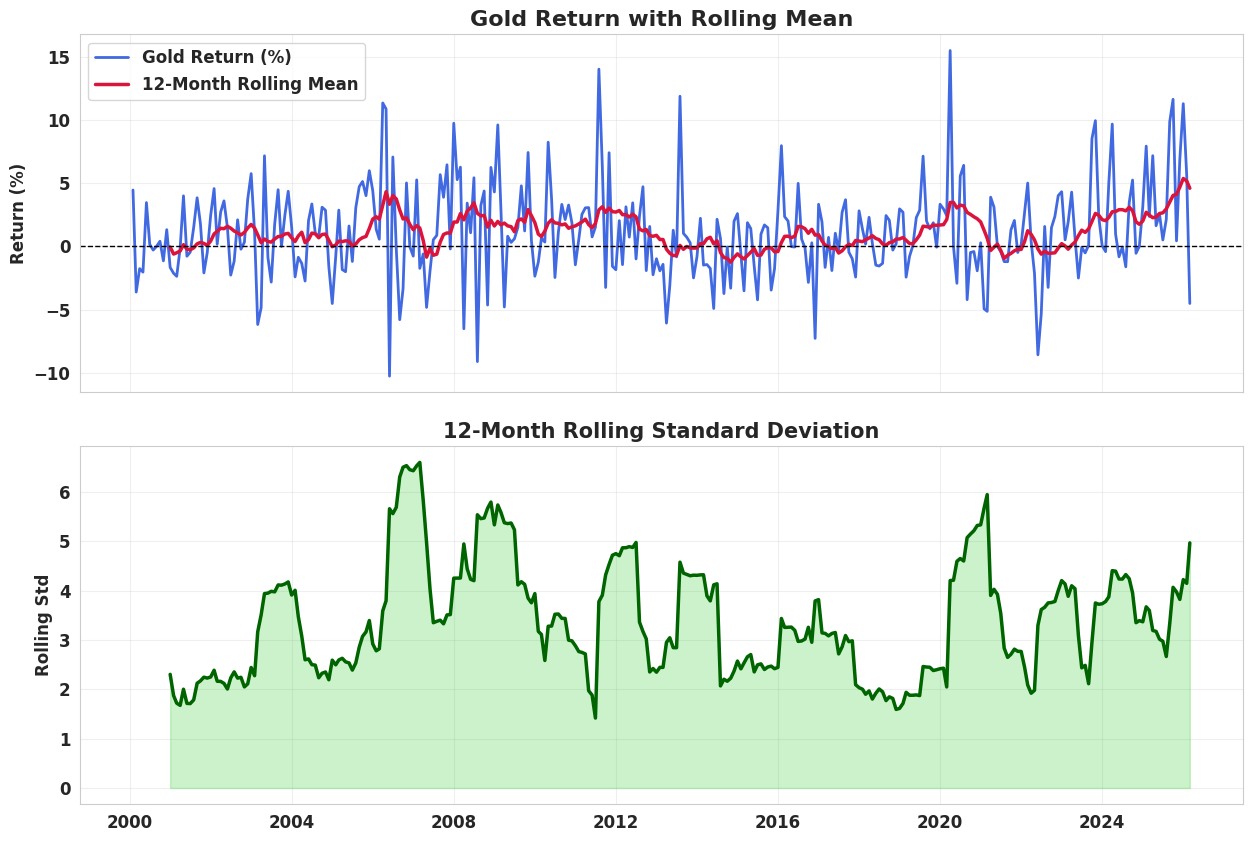

In [13]:
window = 12

rolling_mean_return = gold_return.rolling(window=window).mean()
rolling_std_return = gold_return.rolling(window=window).std()

fig, axes = plt.subplots(
    2, 1,
    figsize=(15,10),
    sharex=True,
    gridspec_kw={'hspace':0.15}
)

# -------------------------------
# Rolling Mean
# -------------------------------

axes[0].plot(
    gold_return,
    color='royalblue',
    linewidth=2,
    label='Gold Return (%)'
)

axes[0].plot(
    rolling_mean_return,
    color='crimson',
    linewidth=2.5,
    label='12-Month Rolling Mean'
)

axes[0].axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1
)

axes[0].set_title(
    'Gold Return with Rolling Mean',
    fontsize=16,
    fontweight='bold'
)

axes[0].set_ylabel('Return (%)')
axes[0].legend(frameon=True)
axes[0].grid(alpha=0.3)

# -------------------------------
# Rolling Standard Deviation
# -------------------------------

axes[1].plot(
    rolling_std_return,
    color='darkgreen',
    linewidth=2.5
)

axes[1].fill_between(
    rolling_std_return.index,
    rolling_std_return.values,
    color='limegreen',
    alpha=0.25
)

axes[1].set_title(
    '12-Month Rolling Standard Deviation',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_ylabel('Rolling Std')
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [15]:
from statsmodels.tsa.stattools import adfuller, kpss

# Install once if not installed
!pip install arch

from arch.unitroot import PhillipsPerron

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.6 MB/s eta 0:00:00


In [16]:
def stationarity_tests(series, series_name):

    print("="*70)
    print(f"Stationarity Tests : {series_name}")
    print("="*70)

    # -----------------------------
    # ADF TEST
    # -----------------------------
    print("\nADF TEST")
    print("-"*30)

    adf_result = adfuller(series.dropna(), autolag='AIC')

    print(f"ADF Statistic : {adf_result[0]:.4f}")
    print(f"P-value       : {adf_result[1]:.4f}")
    print(f"Lags Used     : {adf_result[2]}")
    print(f"Observations  : {adf_result[3]}")

    print("\nCritical Values")

    for key, value in adf_result[4].items():
        print(f"{key}: {value:.4f}")

    if adf_result[1] < 0.05:
        print("\nConclusion : Reject H0 → Stationary")
    else:
        print("\nConclusion : Fail to Reject H0 → Non-Stationary")

    # -----------------------------
    # KPSS TEST
    # -----------------------------
    print("\n\nKPSS TEST")
    print("-"*30)

    kpss_result = kpss(series.dropna(),
                       regression='c',
                       nlags='auto')

    print(f"KPSS Statistic : {kpss_result[0]:.4f}")
    print(f"P-value        : {kpss_result[1]:.4f}")

    print("\nCritical Values")

    for key, value in kpss_result[3].items():
        print(f"{key}: {value}")

    if kpss_result[1] < 0.05:
        print("\nConclusion : Reject H0 → Non-Stationary")
    else:
        print("\nConclusion : Fail to Reject H0 → Stationary")

    # -----------------------------
    # PHILLIPS-PERRON
    # -----------------------------
    print("\n\nPHILLIPS-PERRON TEST")
    print("-"*30)

    pp = PhillipsPerron(series.dropna())

    print(pp.summary())

In [17]:
stationarity_tests(
    gold_price,
    "Gold Price"
)

Stationarity Tests : Gold Price

ADF TEST
------------------------------
ADF Statistic : 2.4306
P-value       : 0.9990
Lags Used     : 14
Observations  : 300

Critical Values
1%: -3.4523
5%: -2.8712
10%: -2.5719

Conclusion : Fail to Reject H0 → Non-Stationary


KPSS TEST
------------------------------
KPSS Statistic : 2.3638
P-value        : 0.0100

Critical Values
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739

Conclusion : Reject H0 → Non-Stationary


PHILLIPS-PERRON TEST
------------------------------
     Phillips-Perron Test (Z-tau)    
Test Statistic                  5.737
P-value                         1.000
Lags                               16
-------------------------------------

Trend: Constant
Critical Values: -3.45 (1%), -2.87 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


/tmp/ipykernel_4438/2197568679.py:36: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(),


In [18]:
stationarity_tests(
    gold_return,
    "Gold Return (%)"
)

Stationarity Tests : Gold Return (%)

ADF TEST
------------------------------
ADF Statistic : -9.0006
P-value       : 0.0000
Lags Used     : 2
Observations  : 311

Critical Values
1%: -3.4516
5%: -2.8709
10%: -2.5717

Conclusion : Reject H0 → Stationary


KPSS TEST
------------------------------
KPSS Statistic : 0.2348
P-value        : 0.1000

Critical Values
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739

Conclusion : Fail to Reject H0 → Stationary


PHILLIPS-PERRON TEST
------------------------------
     Phillips-Perron Test (Z-tau)    
Test Statistic                -15.329
P-value                         0.000
Lags                               16
-------------------------------------

Trend: Constant
Critical Values: -3.45 (1%), -2.87 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


/tmp/ipykernel_4438/2197568679.py:36: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(),


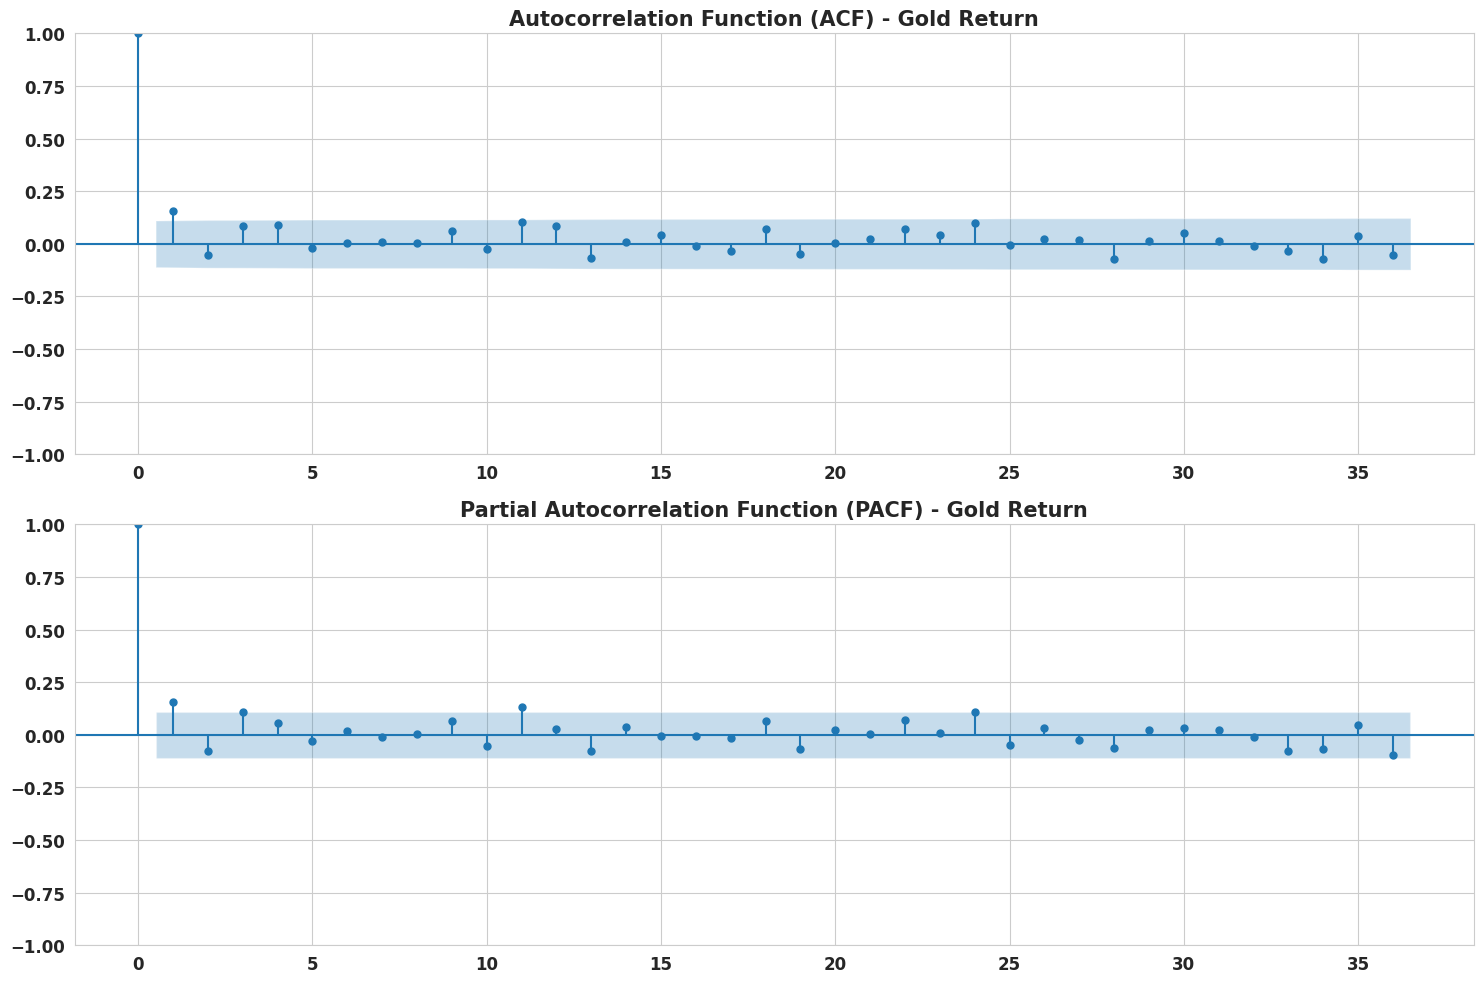

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(15,10))

plot_acf(
    gold_return,
    lags=36,
    ax=axes[0],
    alpha=0.05
)

axes[0].set_title(
    "Autocorrelation Function (ACF) - Gold Return",
    fontsize=15,
    fontweight='bold'
)

plot_pacf(
    gold_return,
    lags=36,
    ax=axes[1],
    method='ywm'
)

axes[1].set_title(
    "Partial Autocorrelation Function (PACF) - Gold Return",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

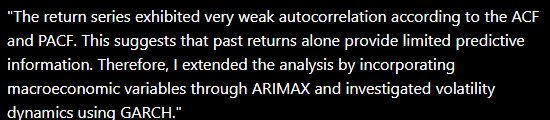

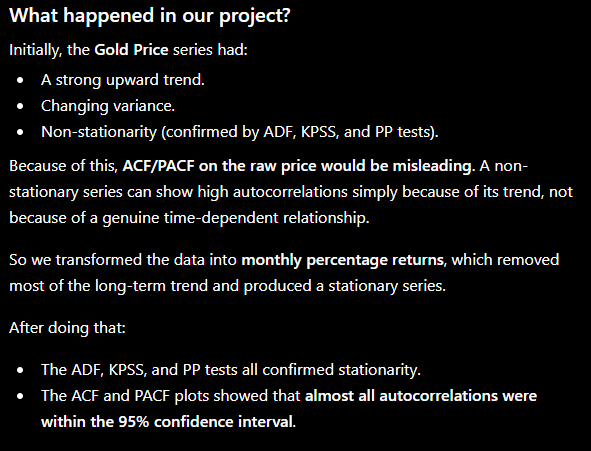

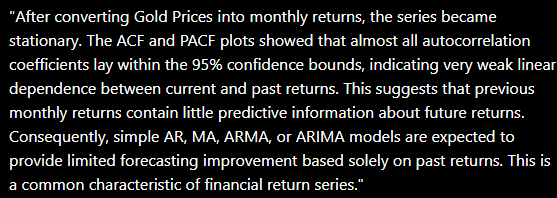

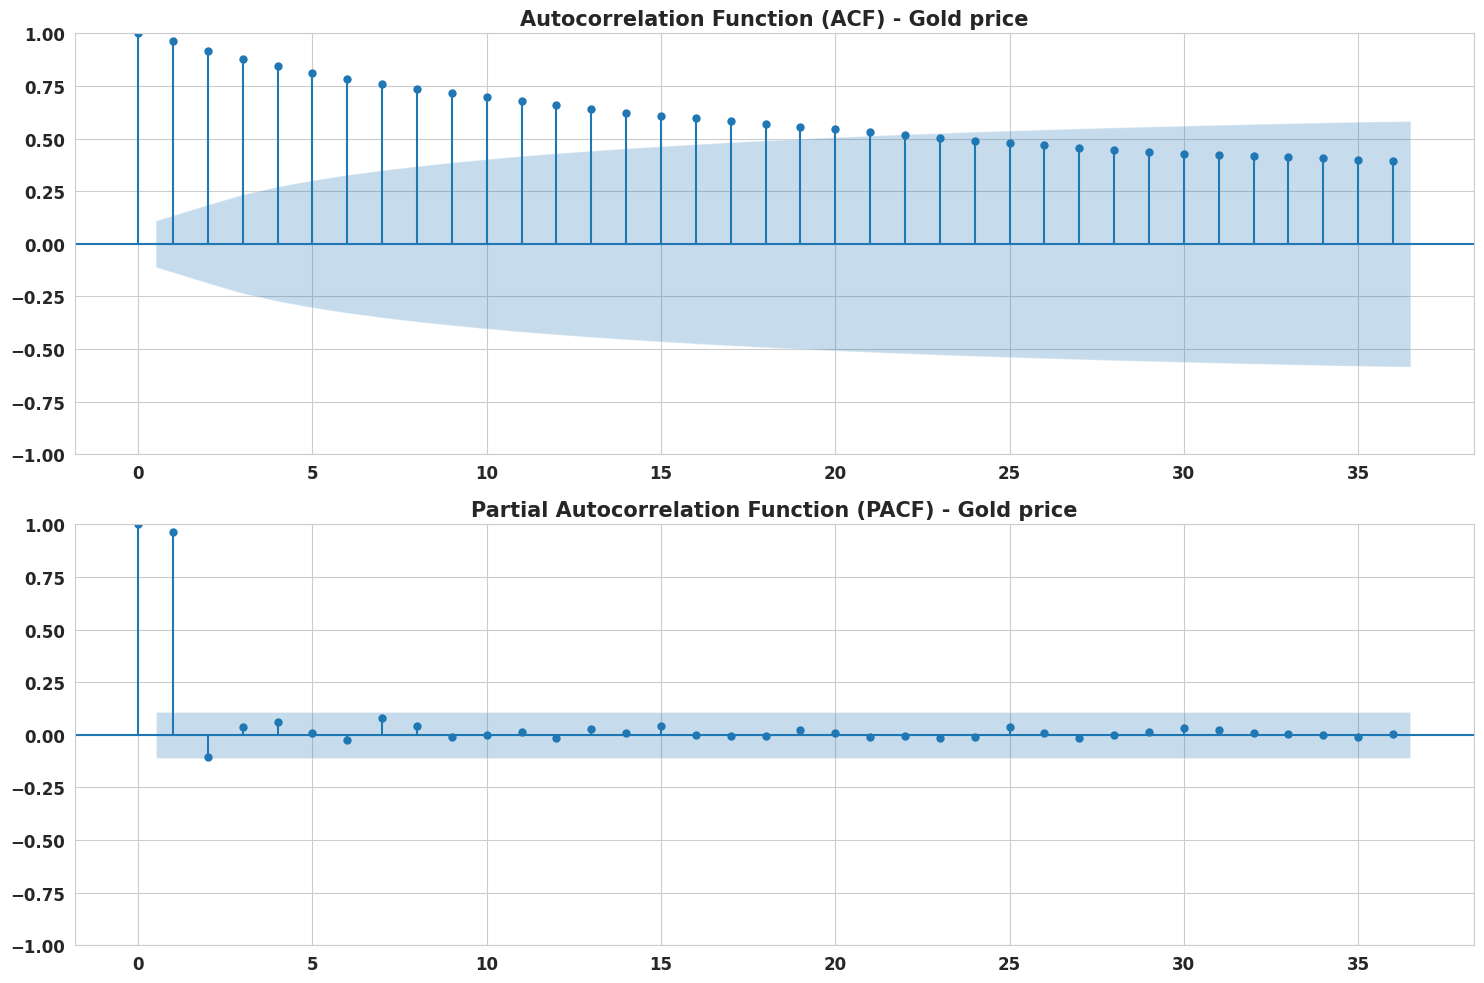

In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(15,10))

plot_acf(
    gold_price,
    lags=36,
    ax=axes[0],
    alpha=0.05
)

axes[0].set_title(
    "Autocorrelation Function (ACF) - Gold price",
    fontsize=15,
    fontweight='bold'
)

plot_pacf(
    gold_price,
    lags=36,
    ax=axes[1],
    method='ywm'
)

axes[1].set_title(
    "Partial Autocorrelation Function (PACF) - Gold price",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.show()